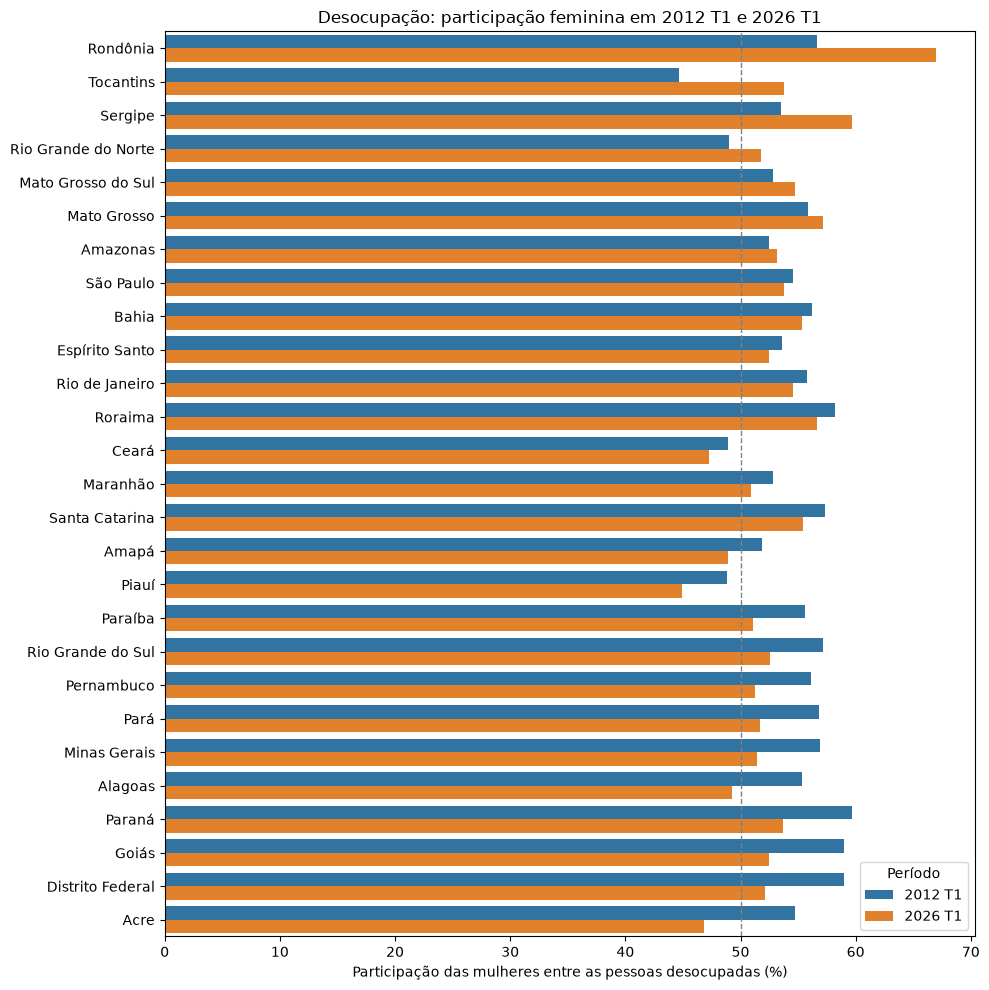

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

t2012 = pd.read_csv(r"H:\Python\3° Etapa\aula6\Tabela5-sem_emprego_2012.csv", sep=";", decimal=",")
t2026 = pd.read_csv(r"H:\Python\3° Etapa\aula6\Tabela5-sem_emprego_2026.csv", sep=";", decimal=",")

tabela_aula2 = pd.read_excel(r"H:\Python\3° Etapa\aula2\Tabela 1.1.1.xls", engine="xlrd", header=None)

t2012.columns = t2012.columns.str.strip()
t2026.columns = t2026.columns.str.strip()

t2012 = t2012.rename(columns={"Desocupados - mulheres (2012 T1)": "mulheres_2012"})
t2026 = t2026.rename(columns={"Desocupados - mulheres (2026 T1)": "mulheres_2026"})

t2012["mulheres_2012"] = t2012["mulheres_2012"].astype(str).str.replace(",", ".")
t2012["mulheres_2012"] = pd.to_numeric(t2012["mulheres_2012"], errors="coerce")

t2026["mulheres_2026"] = t2026["mulheres_2026"].astype(str).str.replace(",", ".")
t2026["mulheres_2026"] = pd.to_numeric(t2026["mulheres_2026"], errors="coerce")

comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

tabela_aula2 = tabela_aula2.iloc[8:].copy()
tabela_aula2.columns = ["Estado", "Total", "Branca", "Preta_ou_parda", "Homem_branca", "Homem_preta_ou_parda", "Mulher_branca", "Mulher_preta_ou_parda"]

tabela_aula2 = tabela_aula2[~tabela_aula2["Estado"].isin(["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"])]
tabela_aula2 = tabela_aula2.dropna(subset=["Estado"])

comp = comp.merge(tabela_aula2, on="Estado", how="inner")

comp["crescimento"] = comp["mulheres_2026"] - comp["mulheres_2012"]

ordem = comp.sort_values("crescimento", ascending=False)["Estado"]

longo = comp.melt(id_vars=["Estado"], value_vars=["mulheres_2012", "mulheres_2026"], var_name="Ano", value_name="Participacao_mulheres")

longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(data=longo, y="Estado", x="Participacao_mulheres", hue="Ano", order=ordem, ax=ax)

ax.axvline(50, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Período")

fig.tight_layout()
plt.show()